# Employee Productivity Loss Prediction Using Logistic Regression

## Project Overview

This project aims to predict whether an employee is experiencing **productivity loss** using workplace, demographic, behavioral, and productivity-related factors.

The dataset contains **1,500 employee records and 30 columns**. A binary target variable, `Productivity_Loss`, is created from `Productivity_Score` to classify employees into two groups:

* **1 — Productivity Loss**
* **0 — No Productivity Loss**

Logistic Regression is used as the classification algorithm, and model performance is evaluated using **Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and ROC-AUC**.

## Objective

The main objectives of this project are:

* Understand the factors associated with employee productivity.
* Prepare and preprocess the dataset for machine learning.
* Create a binary target variable for productivity loss.
* Build a Logistic Regression classification model.
* Evaluate the model using multiple classification metrics.
* Interpret the results from a business perspective.

## Dataset Column Description

| Column Name                    | Description                                                                   |
| ------------------------------ | ----------------------------------------------------------------------------- |
| `Employee_ID`                  | Unique identifier assigned to each employee.                                  |
| `Age`                          | Age of the employee in years.                                                 |
| `Years_Experience`             | Total years of professional work experience.                                  |
| `WFH_Days_Per_Week`            | Number of days the employee works from home per week.                         |
| `Gender`                       | Gender of the employee.                                                       |
| `Education_Level`              | Highest education level attained by the employee.                             |
| `Marital_Status`               | Marital status of the employee.                                               |
| `Has_Children`                 | Indicates whether the employee has children.                                  |
| `Location_Type`                | Type of location where the employee lives, such as Urban, Suburban, or Rural. |
| `Department`                   | Department in which the employee works.                                       |
| `Job_Level`                    | Employee's job seniority level.                                               |
| `Company_Size`                 | Size category of the employee's organization.                                 |
| `Industry`                     | Industry in which the employee works.                                         |
| `Home_Office_Quality`          | Quality of the employee's home-office setup.                                  |
| `Internet_Speed_Category`      | Category representing the employee's internet speed.                          |
| `Work_Hours_Per_Week`          | Number of hours the employee works per week.                                  |
| `Manager_Support_Level`        | Level of support received from the employee's manager.                        |
| `Team_Collaboration_Frequency` | Frequency with which the employee collaborates with their team.               |
| `Task_Completion_Rate`         | Percentage of assigned tasks completed by the employee.                       |
| `Quality_Score`                | Score representing the quality of the employee's work.                        |
| `Innovation_Score`             | Score representing the employee's level of innovation.                        |
| `Efficiency_Rating`            | Rating representing the employee's work efficiency.                           |
| `Meetings_Per_Week`            | Number of meetings attended per week.                                         |
| `Commute_Time_Minutes`         | Average commuting time in minutes.                                            |
| `Job_Satisfaction`             | Score representing the employee's level of job satisfaction.                  |
| `Stress_Level`                 | Score representing the employee's reported stress level.                      |
| `Work_Life_Balance`            | Score representing the employee's work-life balance.                          |
| `Survey_Date`                  | Date on which the employee survey response was recorded.                      |
| `Response_Quality`             | Quality classification of the employee's survey response.                     |
| `Productivity_Score`           | Overall score representing the employee's productivity level.                 |

## Target Variable — Productivity Loss

To convert the continuous `Productivity_Score` into a binary classification problem, the median productivity score is used as the threshold.

* If `Productivity_Score` is **below the median**, `Productivity_Loss = 1`.
* Otherwise, `Productivity_Loss = 0`.

This allows the Logistic Regression model to predict whether an employee belongs to the **productivity-loss group** or the **non-productivity-loss group**.

The target variable is then separated from the predictor variables before model training.


In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv("data/remote_worker_productivity.csv", index_col="Employee_ID"))
df


,Age,Years_Experience,WFH_Days_Per_Week,Gender,Education_Level,Marital_Status,Has_Children,Location_Type,Department,Job_Level,...,Innovation_Score,Efficiency_Rating,Meetings_Per_Week,Commute_Time_Minutes,Job_Satisfaction,Stress_Level,Work_Life_Balance,Survey_Date,Response_Quality,Productivity_Score
Employee_ID,,,,,,,,,,,,,,,,,,,,,
EMP0001,39,10,2,Female,Associate Degree,Married,Yes,Urban,Product,Mid-Level,...,52.1,72.1,4,48,55.9,6,8,05-04-24,Medium,52.2
EMP0002,33,4,5,Female,Master Degree,Married,No,Urban,Customer Success,Senior,...,77.9,89.5,12,0,96.1,3,8,29-01-24,High,81.5
EMP0003,40,3,3,Male,PhD,Single,Yes,Rural,Operations,Mid-Level,...,63.2,95.0,15,24,90.4,5,6,18-01-24,High,82.2
EMP0004,48,14,3,Male,Bachelor Degree,Married,Yes,Urban,Finance,Manager,...,82.5,95.0,8,8,100.0,10,5,18-04-24,High,75.6
EMP0005,32,6,5,Male,High School,Divorced,Yes,Rural,Engineering,Senior,...,67.5,95.0,10,0,100.0,3,4,19-02-24,High,98.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EMP1496,53,5,5,Male,Master Degree,Married,No,Urban,HR,Senior,...,58.3,89.4,9,0,71.4,8,5,18-03-24,High,78.5
EMP1497,53,9,3,Non-binary,Master Degree,Married,Yes,Suburban,Finance,Mid-Level,...,54.2,87.2,3,11,95.8,8,8,13-05-24,High,74.7
EMP1498,45,2,4,Male,Associate Degree,Single,Yes,Suburban,Engineering,Junior,...,71.2,95.0,11,34,100.0,4,5,15-04-24,High,88.6


In [3]:
df.shape

(1500, 29)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1500 entries, EMP0001 to EMP1500
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           1500 non-null   int64  
 1   Years_Experience              1500 non-null   int64  
 2   WFH_Days_Per_Week             1500 non-null   int64  
 3   Gender                        1500 non-null   object 
 4   Education_Level               1500 non-null   object 
 5   Marital_Status                1500 non-null   object 
 6   Has_Children                  1500 non-null   object 
 7   Location_Type                 1500 non-null   object 
 8   Department                    1500 non-null   object 
 9   Job_Level                     1500 non-null   object 
 10  Company_Size                  1500 non-null   object 
 11  Industry                      1500 non-null   object 
 12  Home_Office_Quality           1500 non-null   object 
 13 

In [5]:
df.describe()

,Age,Years_Experience,WFH_Days_Per_Week,Work_Hours_Per_Week,Task_Completion_Rate,Quality_Score,Innovation_Score,Efficiency_Rating,Meetings_Per_Week,Commute_Time_Minutes,Job_Satisfaction,Stress_Level,Work_Life_Balance,Productivity_Score
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,35.190667,4.594667,2.857333,41.734000,82.507133,84.410933,72.821667,90.488533,8.080000,25.465333,95.364400,5.678667,6.221333,83.094867
std,8.406908,4.740607,1.489897,6.038285,15.390392,13.881407,14.994149,9.051719,2.944947,19.056799,9.853226,2.052532,2.088201,15.227276
min,22.000000,0.000000,0.000000,25.000000,40.000000,50.000000,30.000000,43.400000,1.000000,0.000000,35.200000,1.000000,1.000000,35.000000
25%,29.000000,1.000000,2.000000,37.000000,72.200000,75.200000,62.600000,90.475000,6.000000,10.000000,97.250000,4.000000,5.000000,73.700000
50%,35.000000,3.000000,3.000000,42.000000,86.000000,87.600000,74.800000,95.000000,8.000000,25.000000,100.000000,6.000000,6.000000,86.700000
75%,41.000000,7.000000,4.000000,46.000000,96.100000,96.225000,84.200000,95.000000,10.000000,38.000000,100.000000,7.000000,8.000000,98.000000
max,65.000000,32.000000,5.000000,65.000000,100.000000,100.000000,95.000000,95.000000,19.000000,104.000000,100.000000,10.000000,10.000000,98.000000


In [6]:
df.isna().sum()

Age                             0
Years_Experience                0
WFH_Days_Per_Week               0
Gender                          0
Education_Level                 0
Marital_Status                  0
Has_Children                    0
Location_Type                   0
Department                      0
Job_Level                       0
Company_Size                    0
Industry                        0
Home_Office_Quality             0
Internet_Speed_Category         0
Work_Hours_Per_Week             0
Manager_Support_Level           0
Team_Collaboration_Frequency    0
Task_Completion_Rate            0
Quality_Score                   0
Innovation_Score                0
Efficiency_Rating               0
Meetings_Per_Week               0
Commute_Time_Minutes            0
Job_Satisfaction                0
Stress_Level                    0
Work_Life_Balance               0
Survey_Date                     0
Response_Quality                0
Productivity_Score              0
dtype: int64

In [7]:
df[df.duplicated()]

,Age,Years_Experience,WFH_Days_Per_Week,Gender,Education_Level,Marital_Status,Has_Children,Location_Type,Department,Job_Level,...,Innovation_Score,Efficiency_Rating,Meetings_Per_Week,Commute_Time_Minutes,Job_Satisfaction,Stress_Level,Work_Life_Balance,Survey_Date,Response_Quality,Productivity_Score
Employee_ID,,,,,,,,,,,,,,,,,,,,,


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
# Creating a target variable
median_score = df["Productivity_Score"].median()

df["Productivity_Loss"] = (
    df["Productivity_Score"] < median_score
).astype(int)


In [10]:
df["Productivity_Loss"].value_counts()

Productivity_Loss
0    751
1    749
Name: count, dtype: int64

In [11]:
df

,Age,Years_Experience,WFH_Days_Per_Week,Gender,Education_Level,Marital_Status,Has_Children,Location_Type,Department,Job_Level,...,Efficiency_Rating,Meetings_Per_Week,Commute_Time_Minutes,Job_Satisfaction,Stress_Level,Work_Life_Balance,Survey_Date,Response_Quality,Productivity_Score,Productivity_Loss
Employee_ID,,,,,,,,,,,,,,,,,,,,,
EMP0001,39,10,2,Female,Associate Degree,Married,Yes,Urban,Product,Mid-Level,...,72.1,4,48,55.9,6,8,05-04-24,Medium,52.2,1
EMP0002,33,4,5,Female,Master Degree,Married,No,Urban,Customer Success,Senior,...,89.5,12,0,96.1,3,8,29-01-24,High,81.5,1
EMP0003,40,3,3,Male,PhD,Single,Yes,Rural,Operations,Mid-Level,...,95.0,15,24,90.4,5,6,18-01-24,High,82.2,1
EMP0004,48,14,3,Male,Bachelor Degree,Married,Yes,Urban,Finance,Manager,...,95.0,8,8,100.0,10,5,18-04-24,High,75.6,1
EMP0005,32,6,5,Male,High School,Divorced,Yes,Rural,Engineering,Senior,...,95.0,10,0,100.0,3,4,19-02-24,High,98.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EMP1496,53,5,5,Male,Master Degree,Married,No,Urban,HR,Senior,...,89.4,9,0,71.4,8,5,18-03-24,High,78.5,1
EMP1497,53,9,3,Non-binary,Master Degree,Married,Yes,Suburban,Finance,Mid-Level,...,87.2,3,11,95.8,8,8,13-05-24,High,74.7,1
EMP1498,45,2,4,Male,Associate Degree,Single,Yes,Suburban,Engineering,Junior,...,95.0,11,34,100.0,4,5,15-04-24,High,88.6,0


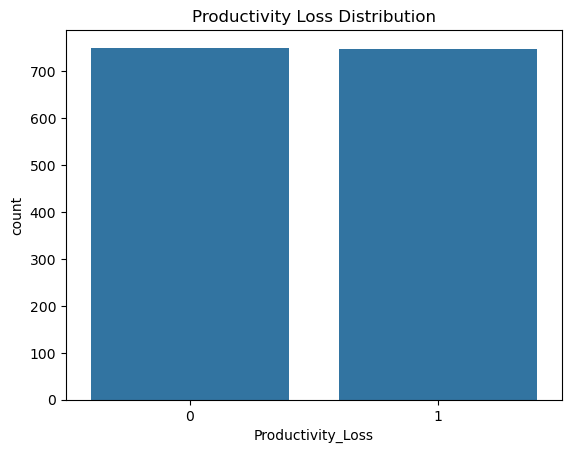

In [12]:
# 1. Productivity Loss Distribution
sns.countplot(
    data=df,
    x="Productivity_Loss"
)

plt.title("Productivity Loss Distribution")
plt.show()

**Insight:** Productivity loss is evenly distributed across employees, providing a balanced dataset for building an accurate classification model.

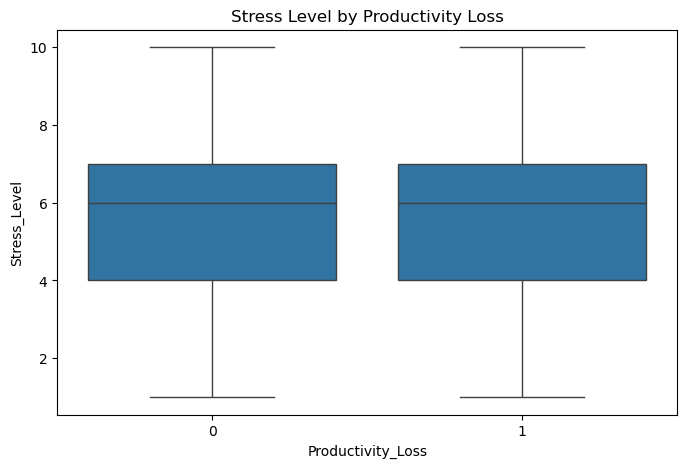

In [13]:
# 2. Stress Level vs Productivity
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Productivity_Loss",
    y="Stress_Level"
)

plt.title("Stress Level by Productivity Loss")
plt.show()

**Insight:** Both groups have an identical median stress level (6) and a similar spread (1–10), indicating a weak relationship between stress and productivity loss.

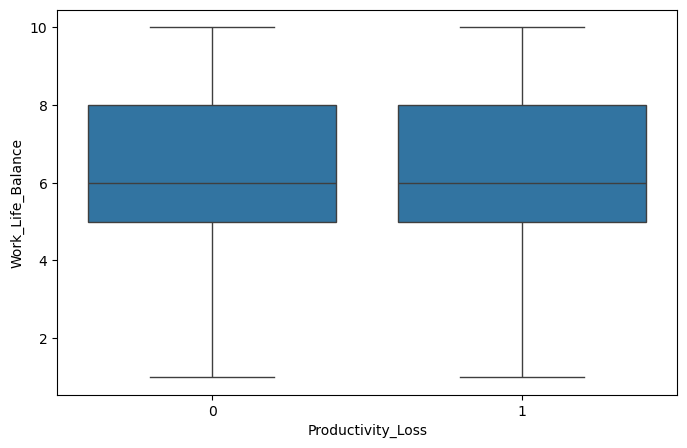

In [14]:
# 3. Work-Life Balance
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Productivity_Loss",
    y="Work_Life_Balance"
)

plt.show()

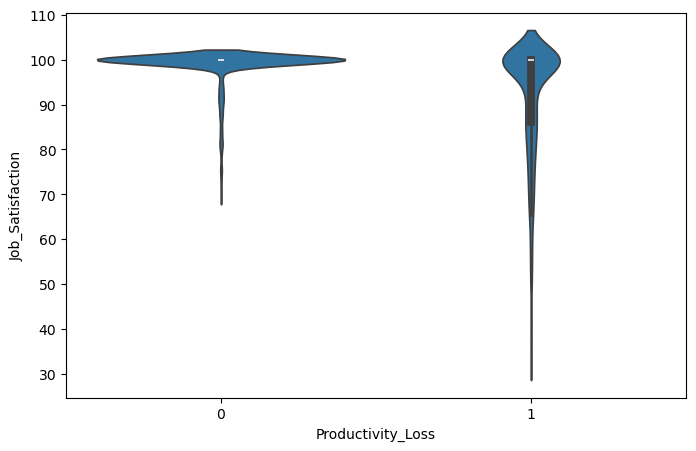

In [15]:
# 4. Job Satisfaction
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x="Productivity_Loss",
    y="Job_Satisfaction"
)

plt.show()

**Insight:** Employees with productivity loss show a wider range of job satisfaction scores (approx. 29–100), indicating more diverse satisfaction levels compared to employees without productivity loss (approx. 68–100).

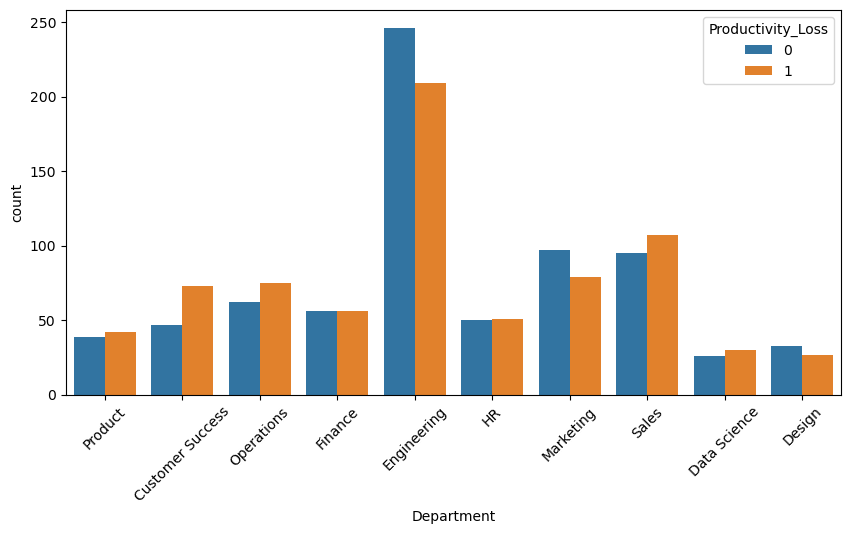

In [16]:
#5. Department Analysis
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Department",
    hue="Productivity_Loss"
)

plt.xticks(rotation=45)
plt.show()

In [17]:
loss_rate = (
    pd.crosstab(
        df["Department"],
        df["Productivity_Loss"],
        normalize="index"
    ) * 100
)

loss_rate = loss_rate.reset_index()
# Sort by Productivity Loss = 1 column
loss_rate = loss_rate.sort_values(by=1, ascending=True)


print(loss_rate.head())

Productivity_Loss   Department          0          1
6                    Marketing  55.113636  44.886364
2                       Design  55.000000  45.000000
3                  Engineering  54.065934  45.934066
4                      Finance  50.000000  50.000000
5                           HR  49.504950  50.495050


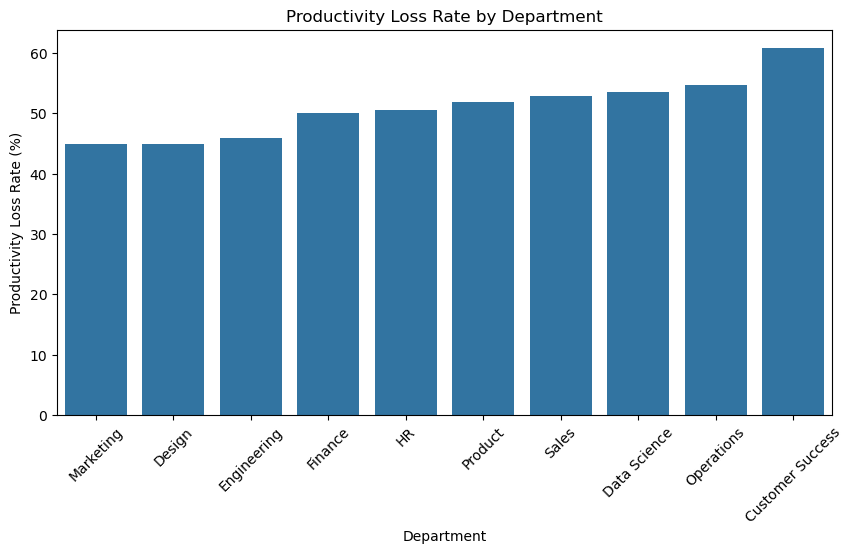

In [18]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=loss_rate,
    x="Department",
    y=1,
    
)

plt.xticks(rotation=45)
plt.ylabel("Productivity Loss Rate (%)")
plt.title("Productivity Loss Rate by Department")
plt.show()

**Insight:** Customer Success is the most affected department (61% productivity loss), while Marketing and Design are the least affected (45% productivity loss).

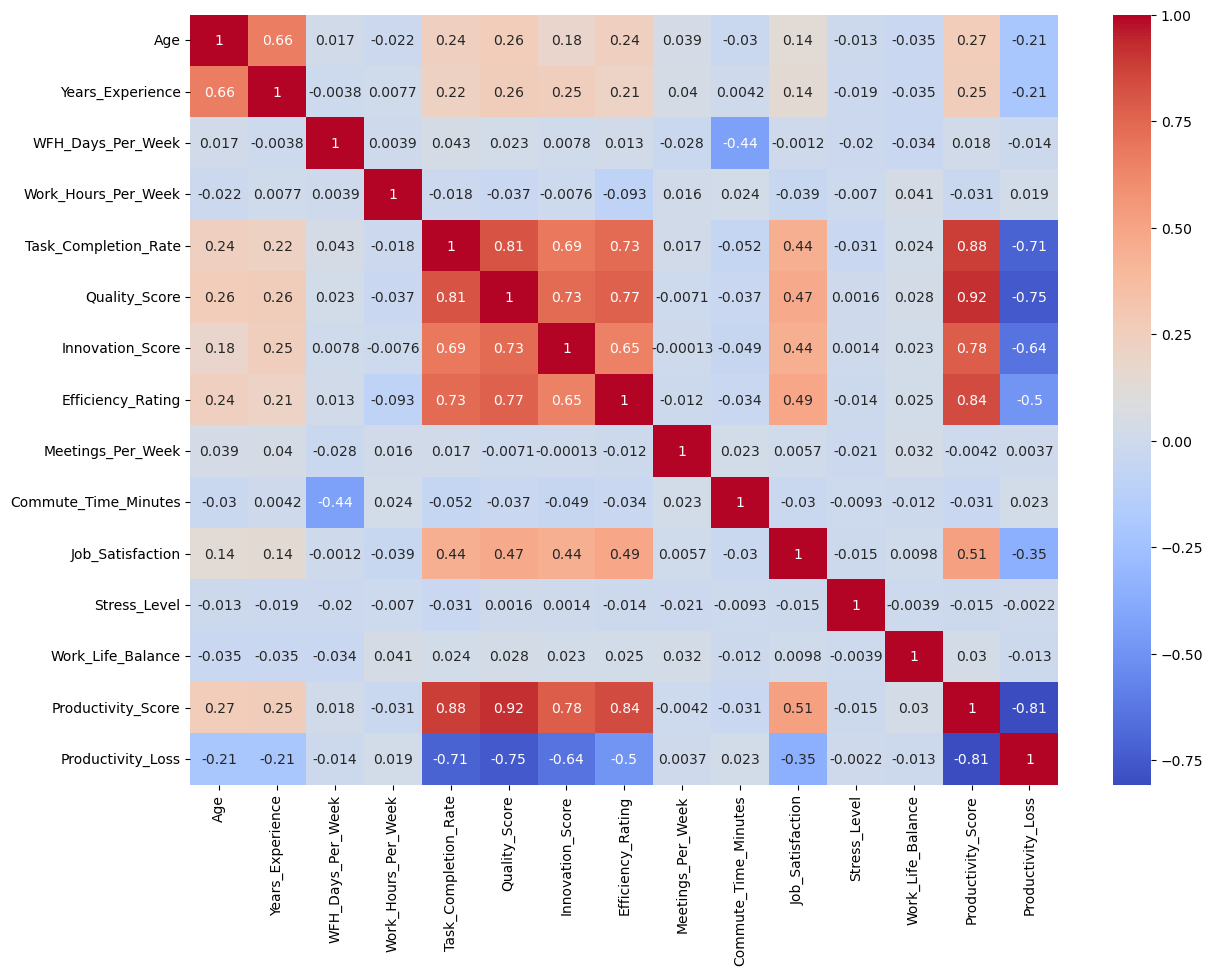

In [19]:
# 6. Correlation Heatmap
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    annot=True
)

plt.show()

**Insight:** Productivity Loss is strongly negatively correlated with Productivity Score (r = -0.81), Quality Score (r = -0.75), Task Completion Rate (r = -0.71), and Innovation Score (r = -0.64). This suggests that employees experiencing productivity loss tend to demonstrate lower overall performance across multiple work-related metrics.

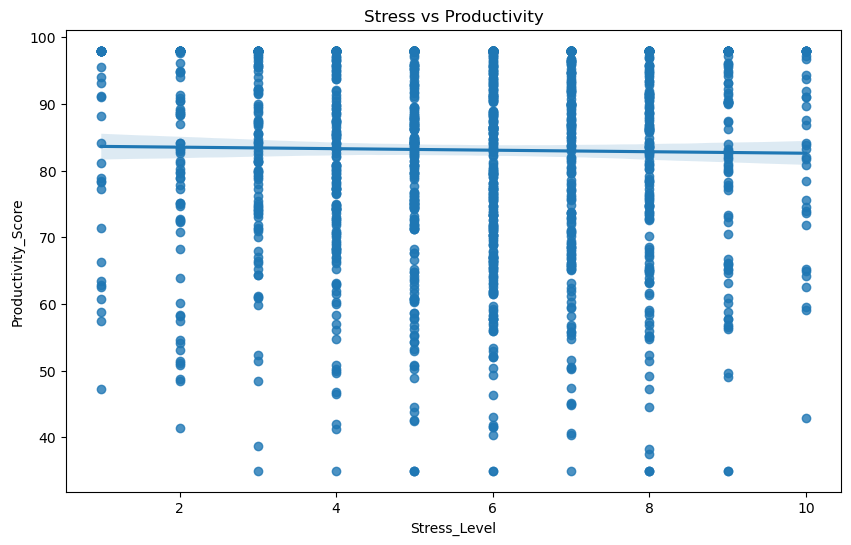

In [20]:
# 7. Stress vs Productivity Score
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="Stress_Level",
    y="Productivity_Score"
)

plt.title("Stress vs Productivity")
plt.show()

**Insight:** Higher stress levels are associated with only a slight decline in productivity, indicating that stress alone is not a major determinant of productivity outcomes.

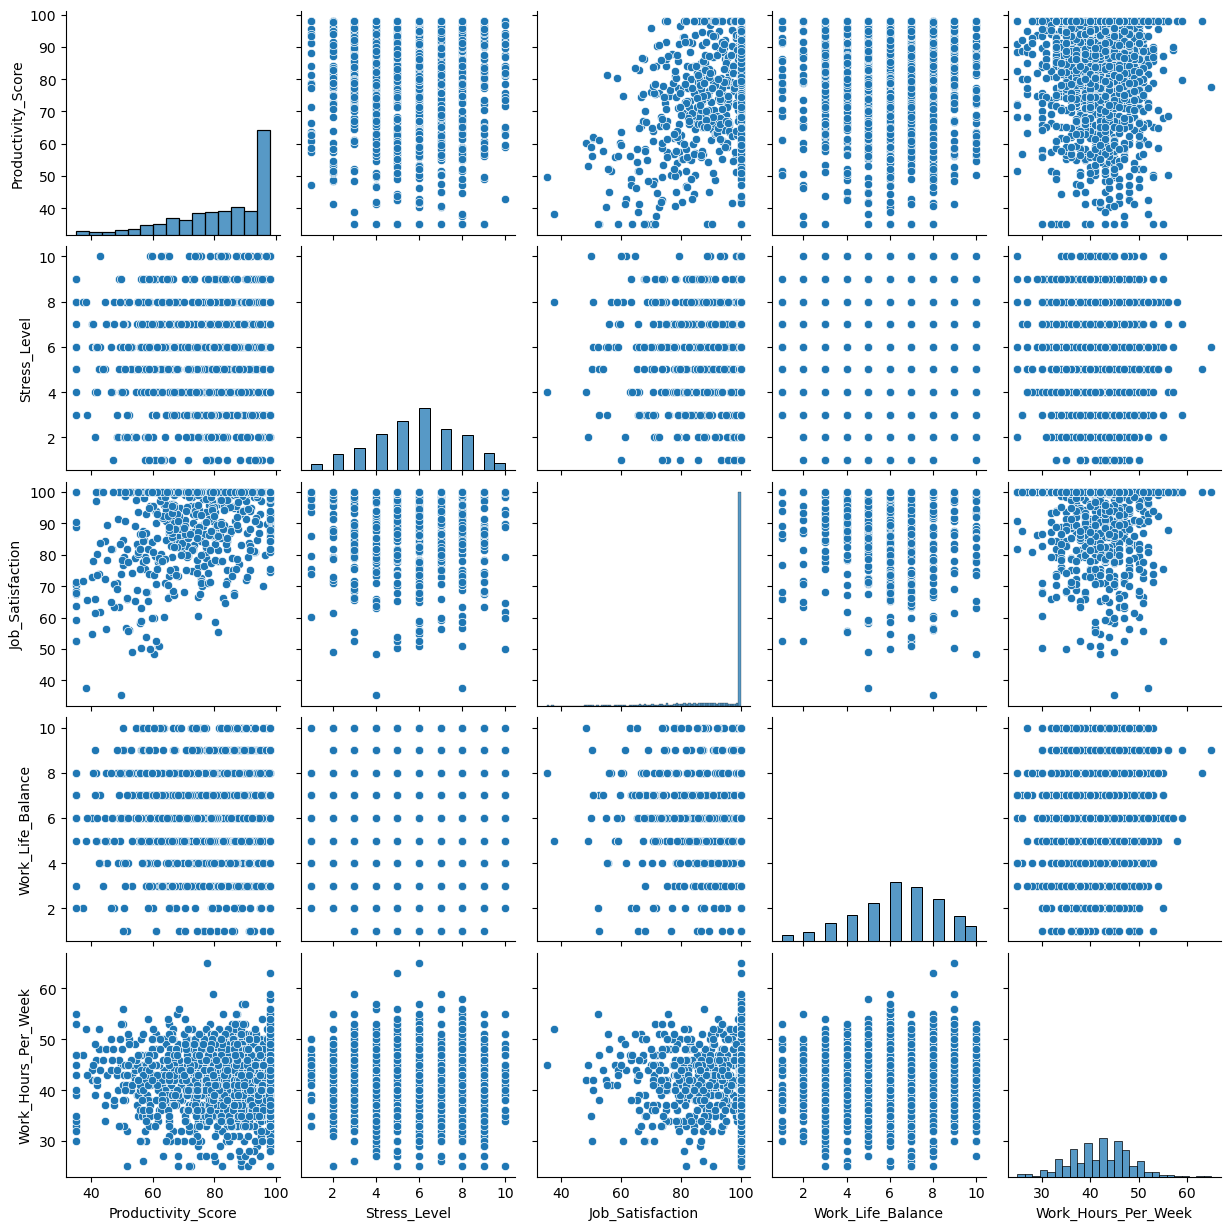

In [21]:
# 8. Pair Plot
cols = [
    'Productivity_Score',
    'Stress_Level',
    'Job_Satisfaction',
    'Work_Life_Balance',
    'Work_Hours_Per_Week'
]

sns.pairplot(df[cols])

plt.show()

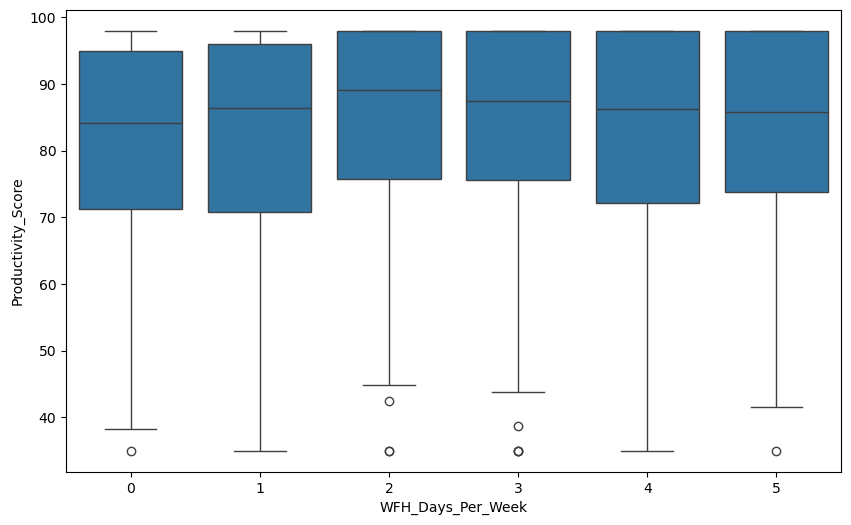

In [22]:
# 9. Productivity Score vs WFH Days per Week
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='WFH_Days_Per_Week',
    y='Productivity_Score'
)

plt.show()

**Insight:** Productivity remains consistently high across all WFH schedules, with a slight peak among employees working remotely 2–3 days per week.

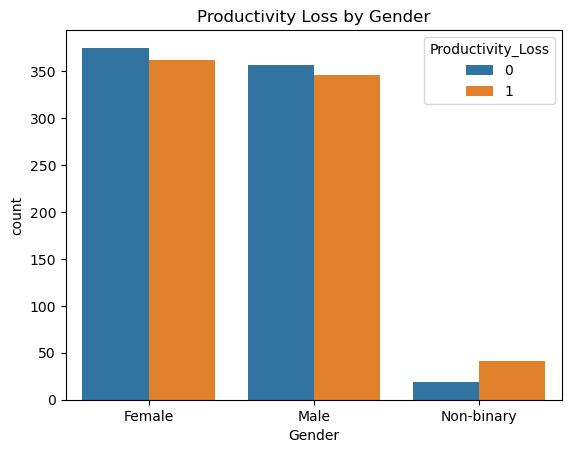

In [23]:
# 10. Productivity Loss by Gender
sns.countplot(
    data=df,
    x='Gender',
    hue='Productivity_Loss'
)

plt.title("Productivity Loss by Gender")
plt.show()

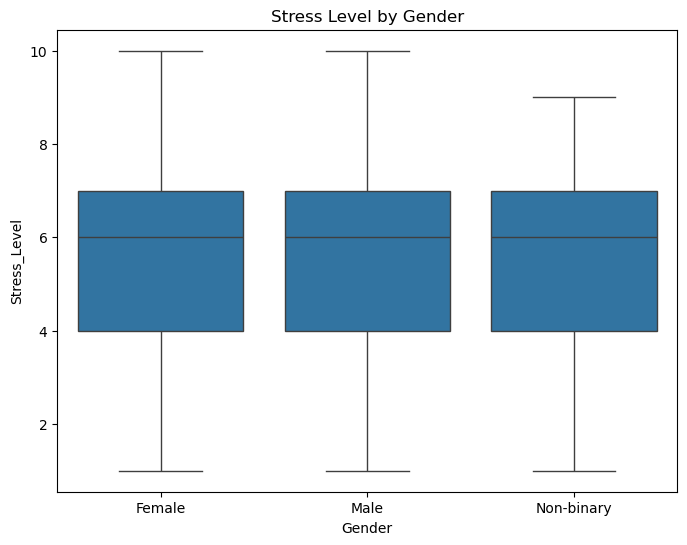

In [24]:
# 11. Productivity Loss by Gender
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='Gender',
    y='Stress_Level'
)

plt.title("Stress Level by Gender")
plt.show()

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score, roc_curve

In [26]:
cat_cols = df.select_dtypes(include ="object").columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [27]:
df

,Age,Years_Experience,WFH_Days_Per_Week,Gender,Education_Level,Marital_Status,Has_Children,Location_Type,Department,Job_Level,...,Efficiency_Rating,Meetings_Per_Week,Commute_Time_Minutes,Job_Satisfaction,Stress_Level,Work_Life_Balance,Survey_Date,Response_Quality,Productivity_Score,Productivity_Loss
Employee_ID,,,,,,,,,,,,,,,,,,,,,
EMP0001,39,10,2,0,0,2,1,2,8,4,...,72.1,4,48,55.9,6,8,18,2,52.2,1
EMP0002,33,4,5,0,3,2,0,2,0,5,...,89.5,12,0,96.1,3,8,113,0,81.5,1
EMP0003,40,3,3,1,4,3,1,0,7,4,...,95.0,15,24,90.4,5,6,69,0,82.2,1
EMP0004,48,14,3,1,1,2,1,2,4,3,...,95.0,8,8,100.0,10,5,72,0,75.6,1
EMP0005,32,6,5,1,2,0,1,0,3,5,...,95.0,10,0,100.0,3,4,74,0,98.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EMP1496,53,5,5,1,3,2,0,2,5,5,...,89.4,9,0,71.4,8,5,71,0,78.5,1
EMP1497,53,9,3,2,3,2,1,1,4,4,...,87.2,3,11,95.8,8,8,51,0,74.7,1
EMP1498,45,2,4,1,0,3,1,1,3,1,...,95.0,11,34,100.0,4,5,59,0,88.6,0


In [28]:
x = df.drop(["Productivity_Score", "Productivity_Loss"],axis=1)
y = df["Productivity_Loss"]

In [29]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

In [31]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(x_train, y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [32]:
y_pred = model.predict(x_test)

In [33]:
# Accuracy Score
accuracy_score(y_test, y_pred)

0.9266666666666666

In [34]:
# Classification report
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       150
           1       0.94      0.91      0.93       150

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300



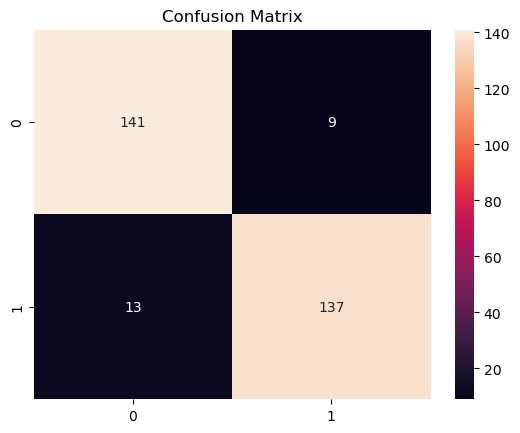

In [35]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.show()

**Insight:** The Logistic Regression model demonstrated excellent performance with 92.67% accuracy, 93% F1-score, and only 22 misclassifications out of 300 test cases, making it an effective tool for predicting employee productivity loss.

In [36]:
# ROC-AUC Section 
y_prob = model.predict_proba(x_test)[:,1]

auc_score = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.9756888888888888


**Insight:** The Logistic Regression model achieved an ROC-AUC score of 0.976, indicating an excellent ability to distinguish between employees experiencing productivity loss and those who are not. The ROC curve remains close to the top-left corner, demonstrating a high True Positive Rate while maintaining a low False Positive Rate.